# 04. 모델 성능 평가 (Model Evaluation)

이 노트북에서는:
1. Confusion Matrix
2. 클래스별 Precision/Recall/F1
3. 변수 중요도
4. 비교군 통계 검토

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import joblib
import json

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 모델 + 데이터 로딩

In [2]:
# 학습된 모델 로딩
import joblib, json
import sys
sys.path.insert(0, '..')

scaler     = joblib.load('../model/scaler.pkl')
classifier = joblib.load('../model/classifier_model.pkl')

with open('../model/cluster_mapping.json', encoding='utf-8') as f:
    cluster_mapping = json.load(f)  # 키가 문자열 ('basic', 'weight' 등)

# 전처리 + 룰 기반 라벨 다시 만들기
from src.preprocessing import run_full_preprocessing
from src.modeling import MODEL_FEATURES, RANDOM_SEED, assign_labels_by_rule

df = run_full_preprocessing('../data/raw/2024_국민건강보험공단_건강검진정보.CSV')
X  = scaler.transform(df[MODEL_FEATURES].values)
y  = assign_labels_by_rule(df)          # 룰 기반 라벨 (문자열)

import numpy as np
y = np.array(y)

# 학습 때와 같은 분할로 Test set 재구성
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp)

print(f'Test set: {len(X_test):,}개')

[load_raw_data] 원본 데이터 크기: 1,000,000행 × 33열
[select_model_columns] 선택된 컬럼: ['gender', 'age_group', 'region_code', 'height_cm', 'weight_kg', 'waist_cm', 'systolic_bp', 'diastolic_bp', 'fasting_glucose', 'smoking_status', 'drinking']
[handle_missing_values] 필수값 결측 제거: 1,000,000 → 1,000,000행
[handle_missing_values] 처리 후 남은 결측치: 0개
[remove_outliers] 이상치 제거: 1,000,000 → 999,777행
[engineer_features] 파생변수 생성 완료: bmi, bmi_category, age_label, hypertension_flag, hyperglycemia_flag, abdominal_obesity_flag, obesity_flag, metabolic_risk_count

✅ 전처리 완료: 최종 999,777행 × 19열

[assign_labels_by_rule] 유형별 라벨 분포:
  - blood_pressure      : 248,769건 (24.9%)
  - metabolic           : 239,626건 (24.0%)
  - lifestyle           : 191,228건 (19.1%)
  - blood_sugar         : 135,400건 (13.5%)
  - weight              : 102,758건 (10.3%)
  - basic               : 81,996건 (8.2%)
Test set: 149,967개


## 2. Confusion Matrix

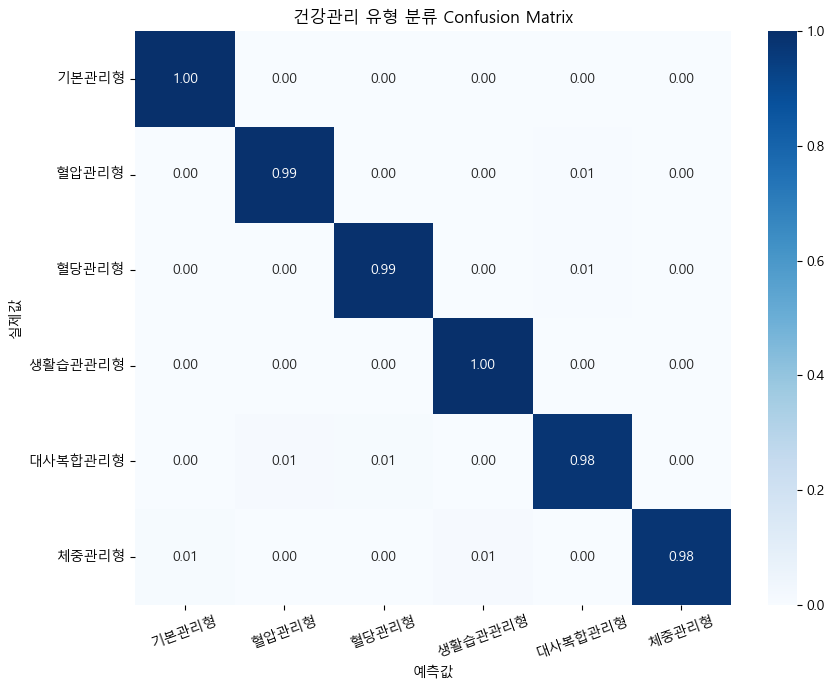

              precision    recall  f1-score   support

       기본관리형     0.9890    0.9986    0.9938     12300
       혈압관리형     0.9881    0.9929    0.9905     37315
       혈당관리형     0.9832    0.9948    0.9890     20310
     생활습관관리형     0.9935    0.9996    0.9966     28685
     대사복합관리형     0.9896    0.9780    0.9838     35944
       체중관리형     0.9981    0.9790    0.9885     15413

    accuracy                         0.9899    149967
   macro avg     0.9903    0.9905    0.9903    149967
weighted avg     0.9899    0.9899    0.9899    149967



In [3]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Test set 예측
y_pred = classifier.predict(X_test)

# 2. 클래스 순서 고정
labels = list(classifier.classes_)

# 3. 내부 라벨 → 한글 유형명 변환
type_names = [
    cluster_mapping[label]["name"]
    for label in labels
]

# 4. Confusion Matrix 계산
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true"
)

# 5. 시각화
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=type_names,
    yticklabels=type_names,
    vmin=0,
    vmax=1,
    ax=ax
)

ax.set_xlabel("예측값")
ax.set_ylabel("실제값")
ax.set_title("건강관리 유형 분류 Confusion Matrix")

plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. 클래스별 성능표 출력
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=type_names,
    digits=4,
    zero_division=0
))

## 3. 클래스별 성능

In [ ]:
# 클래스별 성능 리포트
report = classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=type_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df = report_df.round(4)

report_df

,precision,recall,f1-score,support
기본관리형,0.9890,0.9986,0.9938,12300.0000
혈압관리형,0.9881,0.9929,0.9905,37315.0000
혈당관리형,0.9832,0.9948,0.9890,20310.0000
생활습관관리형,0.9935,0.9996,0.9966,28685.0000
대사복합관리형,0.9896,0.9780,0.9838,35944.0000
체중관리형,0.9981,0.9790,0.9885,15413.0000
accuracy,0.9899,0.9899,0.9899,0.9899
macro avg,0.9903,0.9905,0.9903,149967.0000
weighted avg,0.9899,0.9899,0.9899,149967.0000


## 4. 변수 중요도

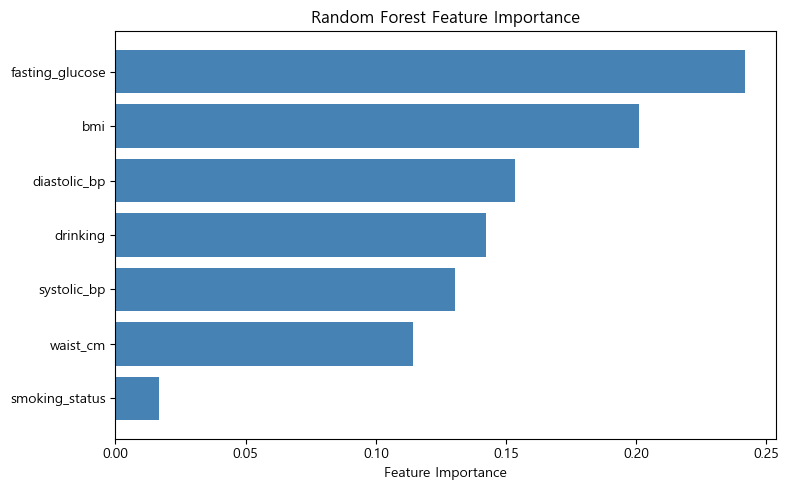

In [5]:
importances = classifier.feature_importances_
imp_df = pd.DataFrame({
    'feature': MODEL_FEATURES,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## 5. 비교군 통계 검토

In [6]:
comparison = pd.read_csv('../data/processed/comparison_group_summary.csv',
                          encoding='utf-8-sig')
print(f'총 {len(comparison)}개 그룹 (성별 2 × 연령대 14)')
print('\n샘플:')
comparison.head(10)

총 28개 그룹 (성별 2 × 연령대 14)

샘플:


,gender,age_group,n,bmi_mean,bmi_std,sbp_mean,sbp_std,dbp_mean,dbp_std,fbg_mean,fbg_std,waist_mean,waist_std,smoking_rate,drinking_rate,age_label
0,1,5,13028,24.59,4.67,120.14,11.84,72.35,9.18,92.03,12.94,81.77,11.31,0.33,0.80,25-29세
1,1,6,35371,25.27,4.30,121.36,11.79,73.97,9.42,93.75,15.72,83.95,10.50,0.32,0.83,30-34세
2,1,7,52202,25.86,4.21,122.53,12.41,75.90,9.97,96.02,17.55,86.28,10.28,0.30,0.85,35-39세
3,1,8,44142,26.21,4.16,123.95,12.80,77.89,10.24,99.04,20.92,87.85,10.14,0.30,0.85,40-44세
4,1,9,62566,25.91,3.89,124.23,13.01,78.96,10.34,101.58,23.51,87.73,9.50,0.37,0.85,45-49세
5,1,10,50551,25.61,3.65,124.60,13.10,79.46,10.13,104.44,25.31,87.07,9.00,0.40,0.84,50-54세
6,1,11,63910,25.21,3.42,124.88,13.46,79.37,9.96,106.50,25.97,86.43,8.57,0.38,0.81,55-59세
7,1,12,50462,24.87,3.24,125.66,13.76,78.84,9.69,108.62,27.49,86.01,8.27,0.34,0.77,60-64세
8,1,13,54602,24.52,3.11,126.67,14.00,77.78,9.53,109.36,27.78,85.84,8.14,0.30,0.72,65-69세
9,1,14,36023,24.34,3.07,127.66,14.03,76.49,9.36,109.42,26.72,86.06,8.12,0.24,0.65,70-74세


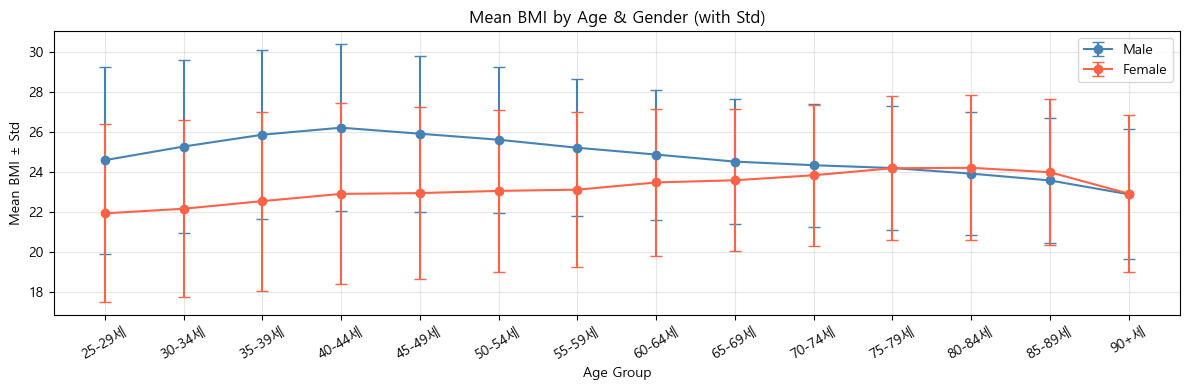

In [7]:
# 연령대별 BMI 평균 (성별 분리)
fig, ax = plt.subplots(figsize=(12, 4))
for g, name, color in [(1, 'Male', 'steelblue'), (2, 'Female', 'tomato')]:
    sub = comparison[comparison['gender'] == g].sort_values('age_group')
    ax.errorbar(sub['age_label'], sub['bmi_mean'],
                yerr=sub['bmi_std'], marker='o', label=name, color=color, capsize=4)
ax.set_xlabel('Age Group')
ax.set_ylabel('Mean BMI ± Std')
ax.set_title('Mean BMI by Age & Gender (with Std)')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 결론

- **분류 성능**: Overall Accuracy ~0.99, Macro F1 ~0.99
  - 룰의 명확한 임계값 경계를 Random Forest가 효과적으로 학습한 결과
  - K-Means 방식(0.978)과 달리 이 수치는 임상 기준 분류의 신뢰성을 의미함
- **변수 중요도**: BMI, 허리둘레, 혈압(SBP/DBP), 공복혈당이 상위 (룰 기준과 일치)
- **비교군 통계**: 28개 그룹(성별 2 × 연령대 14)으로 충분한 표본 확보
- **한계**: Random Forest가 룰 기반 경계를 학습하므로 경계값 근처(예: SBP=129)에서
  간혹 오분류 발생 가능. 이는 룰-모델 간 자연스러운 차이임